# 1) Bağımlılıklar

In [1]:
!pip install -qU llama-index
!pip install -qU llama-index-embeddings-huggingface
!pip install -qU llama-index-retrievers-bm25
!pip install -qU llama-index-postprocessor-flag-embedding-reranker
!pip install -qU sentence-transformers rank_bm25 nest_asyncio
!pip install FlagEmbedding


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.2/121.2 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.4/142.4 kB 10.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.6 which is incompatible.
torch 2.10.0+cu128 requires cuda-bindings==12.9.4; platform_system == "Linux", but you have cuda-bindings 13.2.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 80.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behavio

# 2) Setup

In [ ]:
import os
os.environ["HF_TOKEN"] = ""

import nest_asyncio
nest_asyncio.apply()

import pandas as pd
import asyncio
import gc
import torch
import json
import glob
from typing import List

from llama_index.core import VectorStoreIndex, Document, Settings
from llama_index.core.node_parser import SentenceSplitter, MarkdownNodeParser
from llama_index.embeddings.huggingface import HuggingFaceEmbedding
from llama_index.retrievers.bm25 import BM25Retriever
from llama_index.core.retrievers import QueryFusionRetriever
from llama_index.postprocessor.flag_embedding_reranker import FlagEmbeddingReranker
from llama_index.core.evaluation import QueryResponseDataset
from llama_index.core import SimpleDirectoryReader
from llama_index.core.indices.query.schema import QueryBundle
from llama_index.core.llms import MockLLM
Settings.llm = MockLLM() # OpenAI API kontrolünü tamamen devre dışı bırakır

# ── GPU TESPİTİ ──
print(f"🖥️  Kullanılabilir GPU: {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    name = torch.cuda.get_device_name(i)
    mem = torch.cuda.get_device_properties(i).total_memory / 1024**3
    print(f"   cuda:{i} → {name} ({mem:.1f} GB)")

print("\n⚠️ DİKKAT: Bu notebook 100% stabilite için sadece cuda:0'ı kullanacaktır.")

all_results = []

def add_result(group, model_name, metrics):
    row = {
        "Group": group,
        "System": model_name
    }
    # Dynamically add all metrics to the row
    for k, v in metrics.items():
        row[k] = round(v, 4)
    
    all_results.append(row)
    
    k_to_print = 5 if any("5" in key for key in metrics.keys()) else [int(s) for s in list(metrics.keys())[0].split('@') if s.isdigit()][-1]
    # Tüm metrikleri yazdır (@k_to_print olanları filtreleyelim ki çok kalabalık olmasın)
    metrics_str = " | ".join([f"{k.split('@')[0]}: {metrics.get(k, 0.0):.4f}" for k in metrics.keys() if f"@{k_to_print}" in k])
    print(f"  ✅ [{group}] {model_name} → {metrics_str}")

# ── BATCH DEĞERLENDİRİCİ (Batch Embedding Desteği ve OOM önleyici) ──
async def evaluate_retriever_custom(retriever, queries_dict, relevant_docs_dict, ground_truths_dict,
                                     k_values=[1, 3, 5, 10], max_concurrent=15, batch_size=100,
                                     embed_model=None):
    sem = asyncio.Semaphore(max_concurrent)
    max_k = max(k_values)
    
    # ── BATCH EMBEDDING HIZLANDIRMASI ──
    query_embeddings_dict = {}
    if embed_model is not None:
        try:
            print("      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...")
            q_ids = list(queries_dict.keys())
            q_texts = list(queries_dict.values())
            
            embeddings = embed_model.get_text_embedding_batch(q_texts, show_progress=True)
            query_embeddings_dict = {q_ids[i]: embeddings[i] for i in range(len(q_ids))}
            print("      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...")
        except Exception as e:
            print(f"      ⚠️ Toplu vektörleştirme başarısız oldu, klasik yöntemle devam ediliyor: {e}")
            query_embeddings_dict = {}

    def calculate_standard_metrics(flags, expected_total, k):
        flags_k = flags[:k]
        hit = 1.0 if any(flags_k) else 0.0
        mrr = 0.0
        for i, f in enumerate(flags_k):
            if f:
                mrr = 1.0 / (i + 1)
                break
        precision = sum(flags_k) / k if k > 0 else 0.0
        
        ap = 0.0
        correct_so_far = 0
        for i, f in enumerate(flags_k):
            if f:
                correct_so_far += 1
                ap += correct_so_far / (i + 1)
        map_score = ap / expected_total if expected_total > 0 else 0.0
        return hit, mrr, precision, map_score

    async def process_single_query(q_id, query_str, expected_ids):
        if not expected_ids:
            return None
        expected_ids_clean = [str(eid).strip().split(".")[0] for eid in expected_ids]
        expected_answer = ground_truths_dict.get(q_id, "").strip().lower()

        async with sem:
            try:
                if query_embeddings_dict and q_id in query_embeddings_dict:
                    from llama_index.core.indices.query.schema import QueryBundle
                    bundle = QueryBundle(
                        query_str=query_str,
                        embedding=query_embeddings_dict[q_id]
                    )
                    retrieved_nodes = await retriever.aretrieve(bundle)
                else:
                    retrieved_nodes = await retriever.aretrieve(query_str)
                
                retrieved_nodes = retrieved_nodes[:max_k]

                doc_flags = []
                exact_flags = []

                def tr_normalize(text):
                    text = text.replace('I', 'ı').replace('İ', 'i').lower()
                    import re
                    words = re.findall(r'\w+', text)
                    stopwords = {'ve', 'bir', 'de', 'da', 'en', 'ise', 'ki', 'ile', 'için', 'bu', 'şu', 'o', 'ne', 'ya', 'ama', 'fakat'}
                    return [w for w in words if len(w) > 2 and w not in stopwords]

                expected_words = tr_normalize(ground_truths_dict.get(q_id, ""))

                for n in retrieved_nodes:
                    chunk_text = n.node.get_content().strip()
                    chunk_norm = ' '.join(tr_normalize(chunk_text))
                    
                    possible_ids = []
                    if getattr(n.node, "ref_doc_id", None): possible_ids.append(n.node.ref_doc_id)
                    if getattr(n.node, "node_id", None): possible_ids.append(n.node.node_id)
                    if n.node.metadata and "file_name" in n.node.metadata: possible_ids.append(n.node.metadata["file_name"])

                    doc_match = False
                    for pid in possible_ids:
                        clean_pid = str(pid).strip().split(".")[0]
                        if clean_pid in expected_ids_clean:
                            doc_match = True
                            break
                    doc_flags.append(doc_match)
                    
                    exact_match = False
                    if expected_words:
                        matched_words = sum(1 for w in expected_words if w in chunk_norm)
                        overlap_ratio = matched_words / len(expected_words)
                        if overlap_ratio >= 0.70:
                            exact_match = True
                    exact_flags.append(exact_match)

                total_expected_docs = len(expected_ids_clean)
                
                metrics_dict = {}
                for k in k_values:
                    # Calculate Doc metrics for K
                    d_hit, d_mrr, d_prec, d_map = calculate_standard_metrics(doc_flags, total_expected_docs, k)
                    
                    # Calculate Recall differently since it's based on unique docs retrieved within top-K
                    found_docs_k = set()
                    for i in range(min(k, len(retrieved_nodes))):
                        if doc_flags[i]:
                            # Find which expected doc this was (for recall calculation). This is simplified.
                            # We just assume all hits are unique for now, but to be strictly correct, 
                            # we count unique doc_ids found in top K.
                            n = retrieved_nodes[i]
                            for pid in [getattr(n.node, "ref_doc_id", None), getattr(n.node, "node_id", None), n.node.metadata.get("file_name", None)]:
                                if pid:
                                    c_pid = str(pid).strip().split(".")[0]
                                    if c_pid in expected_ids_clean:
                                        found_docs_k.add(c_pid)
                    
                    d_recall = len(found_docs_k) / total_expected_docs if total_expected_docs > 0 else 0.0
                    
                    metrics_dict.update({
                        f"Doc_HitRate@{k}": d_hit, f"Doc_MRR@{k}": d_mrr, f"Doc_Precision@{k}": d_prec, 
                        f"Doc_Recall@{k}": d_recall, f"Doc_MAP@{k}": d_map
                    })

                    # Calculate Exact metrics for K
                    e_hit, e_mrr, e_prec, e_map = calculate_standard_metrics(exact_flags, 1, k)
                    e_recall = e_hit # Since there is 1 expected exact answer
                    
                    metrics_dict.update({
                        f"Exact_HitRate@{k}": e_hit, f"Exact_MRR@{k}": e_mrr, f"Exact_Precision@{k}": e_prec, 
                        f"Exact_Recall@{k}": e_recall, f"Exact_MAP@{k}": e_map
                    })

                return metrics_dict
            except Exception as e:
                return None

    all_items = list(queries_dict.items())
    all_query_results = []
    total_batches = (len(all_items) + batch_size - 1) // batch_size

    for i in range(0, len(all_items), batch_size):
        batch = all_items[i : i + batch_size]
        batch_num = i // batch_size + 1
        print(f"    Batch {batch_num}/{total_batches} ({len(batch)} sorgu)...", end="\r")

        tasks = [
            process_single_query(q_id, q_str, relevant_docs_dict.get(q_id, []))
            for q_id, q_str in batch
        ]
        batch_results = await asyncio.gather(*tasks)
        all_query_results.extend(batch_results)

    print(f"    ✓ {len(all_items)} sorgu tamamlandı.                        ")

    valid_results = [r for r in all_query_results if r is not None]
    if not valid_results:
        # Return zeros for all keys
        empty_metrics = {}
        for k in k_values:
            for pfx in ["Doc_", "Exact_"]:
                for met in ["HitRate", "MRR", "Precision", "Recall", "MAP"]:
                    empty_metrics[f"{pfx}{met}@{k}"] = 0.0
        return empty_metrics

    def avg(key):
        return sum(r[key] for r in valid_results) / len(valid_results)

    return {k: avg(k) for k in valid_results[0].keys()}

print("✅ Setup tamamlandı.")


🖥️  Kullanılabilir GPU: 2
   cuda:0 → Tesla T4 (14.6 GB)
   cuda:1 → Tesla T4 (14.6 GB)

⚠️ DİKKAT: Bu notebook 100% stabilite için sadece cuda:0'ı kullanacaktır.
✅ Setup tamamlandı.


# 3) Veri Yükleme

In [3]:
# BASE_PATH Kendi yolunuza göre ayarlayın
BASE_PATH = "/kaggle/input/datasets/yekbun/turkish-rag-dataset/rag-dataset"

QA_PATH   = os.path.join(BASE_PATH, "benchmark")
DOCS_PATH = os.path.join(BASE_PATH, "stage2_cleaned")

print("1. Dokümanlar yükleniyor...")
reader = SimpleDirectoryReader(input_dir=DOCS_PATH, recursive=True, required_exts=[".md", ".txt"])
documents = reader.load_data()

for doc in documents:
    doc.id_ = doc.metadata["file_name"].replace(".md", "").replace(".txt", "").strip()

print(f"   Toplam Doküman: {len(documents)}")

print("\n2. QA Çiftleri yükleniyor...")
queries = {}
relevant_docs = {}
ground_truths = {} # YENİ EKLENEN: Gerçek cevapları saklayacağımız sözlük

qa_files = glob.glob(os.path.join(QA_PATH, "*.json"))

for file_path in qa_files:
    # Her durumda ground_truths sözlüğünü doldurmak için dosyayı manuel olarak da yükleyip okuyoruz
    try:
        with open(file_path, "r", encoding="utf-8") as f:
            qa_data = json.load(f)
        if isinstance(qa_data, list):
            for idx, item in enumerate(qa_data):
                q_id = item.get("id", item.get("query_id", f"{os.path.basename(file_path)}_{idx}"))
                ground_truths[q_id] = item.get("ground_truth", "")
        
        temp_dataset = QueryResponseDataset.from_json(file_path)
        queries.update(temp_dataset.queries)
        for k, v in temp_dataset.relevant_docs.items():
            relevant_docs[k] = relevant_docs.get(k, []) + v
    except Exception:
        with open(file_path, "r", encoding="utf-8") as f:
            qa_data = json.load(f)

        for idx, item in enumerate(qa_data):
            q_id = item.get("id", item.get("query_id", f"{os.path.basename(file_path)}_{idx}"))
            queries[q_id] = item.get("query", item.get("question", ""))
            
            exp_docs = item.get("source_file", item.get("expected_doc_id", item.get("doc_id", [])))
            if not isinstance(exp_docs, list):
                exp_docs = [exp_docs]
            relevant_docs[q_id] = exp_docs
            
            # CEVAP METNINI AL
            ground_truths[q_id] = item.get("ground_truth", "")

TEST_LIMIT = None  # Hızlı test için sayı verebilirsiniz (örn: 50)
if TEST_LIMIT and TEST_LIMIT < len(queries):
    queries = dict(list(queries.items())[:TEST_LIMIT])
    relevant_docs = {k: relevant_docs.get(k, []) for k in queries.keys()}

print(f"   Toplam Soru: {len(queries)}")


1. Dokümanlar yükleniyor...
   Toplam Doküman: 235

2. QA Çiftleri yükleniyor...
   Toplam Soru: 2132


# 4) Grup 1: Embedding Modeli Karşılaştırması

In [4]:
print("\n" + "=" * 60)
print("  GRUP 1: EMBEDDING MODELİ KARŞILAŞTIRMASI")
print("=" * 60)

embedding_models = {
    "RAG-1": "BAAI/bge-m3",
    "RAG-2": "intfloat/multilingual-e5-large",
    "RAG-3": "sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
}

group1_results = []

async def _eval_embedding(rag_id, model_name):
    print(f"\n🚀 {rag_id} ({model_name.split('/')[-1]}) değerlendiriliyor...")

    embed_model = HuggingFaceEmbedding(
        model_name=model_name,
        device="cuda:0",
        embed_batch_size=32, 
    )

    index = VectorStoreIndex.from_documents(
        documents,
        embed_model=embed_model,
        transformations=[SentenceSplitter(chunk_size=512, chunk_overlap=128)],
    )
    retriever = index.as_retriever(similarity_top_k=10)

    metrics = await evaluate_retriever_custom(retriever, queries, relevant_docs, ground_truths,
        k_values=[1, 3, 5, 10], max_concurrent=20, batch_size=100,
        embed_model=embed_model,
    )

    add_result("Group 1", f"{rag_id} ({model_name.split('/')[-1]})", metrics)
    group1_results.append({"name": model_name, "mrr": metrics.get('Exact_MRR@5', 0.0)})

    # Çok derin hafıza temizliği (LlamaIndex arka plan sızıntılarını engellemek için)
    try:
        del embed_model._model
    except:
        pass
    try:
        del embed_model.model
    except:
        pass
    
    del index
    del retriever
    del embed_model
    
    for _ in range(3):
        gc.collect()
        
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()

for rag_id, model_name in embedding_models.items():
    await _eval_embedding(rag_id, model_name)

best_embedding_model = max(group1_results, key=lambda x: x["mrr"])["name"]
print(f"\n🏆 GRUP 1 KAZANANI: {best_embedding_model}")

Settings.embed_model = HuggingFaceEmbedding(
    model_name=best_embedding_model,
    device="cuda:0",
    embed_batch_size=32,
)



  GRUP 1: EMBEDDING MODELİ KARŞILAŞTIRMASI

🚀 RAG-1 (bge-m3) değerlendiriliyor...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 1] RAG-3 (paraphrase-multilingual-mpnet-base-v2) → Doc_HitRate: 0.8677 | Doc_MRR: 0.7569 | Doc_Precision: 0.5283 | Doc_Recall: 0.8677 | Doc_MAP: 2.3726 | Exact_HitRate: 0.3016 | Exact_MRR: 0.2241 | Exact_Precision: 0.0734 | Exact_Recall: 0.3016 | Exact_MAP: 0.2760

🏆 GRUP 1 KAZANANI: intfloat/multilingual-e5-large


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 5) Grup 2: Chunk Stratejisi Karşılaştırması

In [5]:
print("\n" + "=" * 60)
print("  GRUP 2: CHUNK STRATEJİSİ KARŞILAŞTIRMASI")
print("=" * 60)

chunk_strategies = {
    "RAG-4 (256/50)":     SentenceSplitter(chunk_size=256, chunk_overlap=50),
    "RAG-5 (1024/200)":   SentenceSplitter(chunk_size=1024, chunk_overlap=200),
    "RAG-6 (Header Based)": MarkdownNodeParser(),
}

group2_results = []

async def _eval_chunk(strategy_name, splitter):
    print(f"\n🚀 {strategy_name} değerlendiriliyor...")

    # Global embed_model kullanılarak gereksiz model yükleme süresi sıfırlandı
    embed_model = Settings.embed_model

    index = VectorStoreIndex.from_documents(
        documents,
        embed_model=embed_model,
        transformations=[splitter],
    )
    retriever = index.as_retriever(similarity_top_k=10)

    metrics = await evaluate_retriever_custom(retriever, queries, relevant_docs, ground_truths,
        k_values=[1, 3, 5, 10], max_concurrent=20, batch_size=100,
        embed_model=embed_model,
    )

    add_result("Group 2", strategy_name, metrics)
    group2_results.append({"name": strategy_name, "splitter": splitter, "mrr": metrics.get('Exact_MRR@5', 0.0)})

    # Yalnızca index ve retriever temizlenir, embed_model tekrar kullanılacağı için silinmez
    del index
    del retriever
    
    for _ in range(3):
        gc.collect()
        
    torch.cuda.empty_cache()
    if hasattr(torch.cuda, "ipc_collect"):
        torch.cuda.ipc_collect()

for name, splitter in chunk_strategies.items():
    await _eval_chunk(name, splitter)

best_chunk = max(group2_results, key=lambda x: x["mrr"])
print(f"\n🏆 GRUP 2 KAZANANI: {best_chunk['name']}")

Settings.text_splitter = best_chunk["splitter"]



  GRUP 2: CHUNK STRATEJİSİ KARŞILAŞTIRMASI

🚀 RAG-4 (256/50) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 2] RAG-4 (256/50) → Doc_HitRate: 0.9756 | Doc_MRR: 0.9421 | Doc_Precision: 0.7934 | Doc_Recall: 0.9756 | Doc_MAP: 3.8278 | Exact_HitRate: 0.4184 | Exact_MRR: 0.3466 | Exact_Precision: 0.1077 | Exact_Recall: 0.4184 | Exact_MAP: 0.4421

🚀 RAG-5 (1024/200) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 2] RAG-5 (1024/200) → Doc_HitRate: 0.9639 | Doc_MRR: 0.9154 | Doc_Precision: 0.7078 | Doc_Recall: 0.9639 | Doc_MAP: 3.3627 | Exact_HitRate: 0.6074 | Exact_MRR: 0.5155 | Exact_Precision: 0.1756 | Exact_Recall: 0.6074 | Exact_MAP: 0.7418

🚀 RAG-6 (Header Based) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 2] RAG-6 (Header Based) → Doc_HitRate: 0.9264 | Doc_MRR: 0.8475 | Doc_Precision: 0.6036 | Doc_Recall: 0.9264 | Doc_MAP: 2.7956 | Exact_HitRate: 0.5821 | Exact_MRR: 0.4699 | Exact_Precision: 0.1509 | Exact_Recall: 0.5821 | Exact_MAP: 0.6074

🏆 GRUP 2 KAZANANI: RAG-5 (1024/200)


# 6) Grup 3: Retrieval Stratejisi (BM25 + Hybrid)

In [6]:
print("\n" + "=" * 60)
print("  GRUP 3: RETRIEVAL STRATEJİSİ KARŞILAŞTIRMASI")
print("=" * 60)
gc.collect()
torch.cuda.empty_cache()

# En iyi embedding modeli ve en iyi chunking stratejisi ile best_index'i yeniden oluşturuyoruz
print("🚀 En iyi konfigürasyon ile best_index oluşturuluyor...")
best_index = VectorStoreIndex.from_documents(
    documents,
    embed_model=Settings.embed_model,
    transformations=[Settings.text_splitter],
)

vector_retriever = best_index.as_retriever(similarity_top_k=10)
nodes = list(best_index.docstore.docs.values())
bm25_retriever = BM25Retriever.from_defaults(nodes=nodes, similarity_top_k=10)

from llama_index.core.llms import MockLLM
hybrid_retriever = QueryFusionRetriever(
    [vector_retriever, bm25_retriever],
    similarity_top_k=10,
    num_queries=1,
    use_async=True,
    llm=MockLLM(),
)

print("\n🚀 RAG-7 (BM25 Only) değerlendiriliyor...")

metrics = await evaluate_retriever_custom(bm25_retriever, queries, relevant_docs, ground_truths,
    k_values=[1, 3, 5, 10], max_concurrent=20, batch_size=100,
)
add_result("Group 3", "RAG-7 (BM25 Only)", metrics)

print("\n🚀 RAG-8 (Hybrid: Vector + BM25) değerlendiriliyor...")
metrics = await evaluate_retriever_custom(hybrid_retriever, queries, relevant_docs, ground_truths,
    k_values=[1, 3, 5, 10], max_concurrent=20, batch_size=100,
    embed_model=Settings.embed_model, # Toplu vektörleştirme parametresi eklendi!
)
add_result("Group 3", "RAG-8 (Hybrid: Vector + BM25)", metrics)



  GRUP 3: RETRIEVAL STRATEJİSİ KARŞILAŞTIRMASI
🚀 En iyi konfigürasyon ile best_index oluşturuluyor...

🚀 RAG-7 (BM25 Only) değerlendiriliyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 3] RAG-7 (BM25 Only) → Doc_HitRate: 0.9780 | Doc_MRR: 0.9469 | Doc_Precision: 0.7075 | Doc_Recall: 0.9780 | Doc_MAP: 3.3866 | Exact_HitRate: 0.6276 | Exact_MRR: 0.5651 | Exact_Precision: 0.1902 | Exact_Recall: 0.6276 | Exact_MAP: 0.8528

🚀 RAG-8 (Hybrid: Vector + BM25) değerlendiriliyor...
      ⚡ Değerlendirme öncesi tüm sorgular GPU'da toplu olarak vektörleştiriliyor (Batch embedding)...


Generating embeddings:   0%|          | 0/2132 [00:00<?, ?it/s]

      ✓ Sorgu vektörleştirme tamamlandı! Arama ve değerlendirme başlıyor...
    ✓ 2132 sorgu tamamlandı.                        
  ✅ [Group 3] RAG-8 (Hybrid: Vector + BM25) → Doc_HitRate: 0.9780 | Doc_MRR: 0.9467 | Doc_Precision: 0.7081 | Doc_Recall: 0.9780 | Doc_MAP: 3.3884 | Exact_HitRate: 0.6276 | Exact_MRR: 0.5651 | Exact_Precision: 0.1902 | Exact_Recall: 0.6276 | Exact_MAP: 0.8528


# 7) Sonuç Tablosu

In [7]:
print("\n" + "=" * 60)
print("  🏆 TÜM RAG SİSTEMLERİ PERFORMANS TABLOSU 🏆")
print("=" * 60)

df_results = pd.DataFrame(all_results)
pd.set_option('display.max_columns', None)
display(df_results.sort_values(by=["Group", "Exact_MRR@5"], ascending=[True, False]))

df_results.to_csv("rag_evaluation_results.csv", index=False)



  🏆 TÜM RAG SİSTEMLERİ PERFORMANS TABLOSU 🏆


,Group,System,Doc_HitRate@1,Doc_MRR@1,Doc_Precision@1,Doc_Recall@1,Doc_MAP@1,Exact_HitRate@1,Exact_MRR@1,Exact_Precision@1,Exact_Recall@1,Exact_MAP@1,Doc_HitRate@3,Doc_MRR@3,Doc_Precision@3,Doc_Recall@3,Doc_MAP@3,Exact_HitRate@3,Exact_MRR@3,Exact_Precision@3,Exact_Recall@3,Exact_MAP@3,Doc_HitRate@5,Doc_MRR@5,Doc_Precision@5,Doc_Recall@5,Doc_MAP@5,Exact_HitRate@5,Exact_MRR@5,Exact_Precision@5,Exact_Recall@5,Exact_MAP@5,Doc_HitRate@10,Doc_MRR@10,Doc_Precision@10,Doc_Recall@10,Doc_MAP@10,Exact_HitRate@10,Exact_MRR@10,Exact_Precision@10,Exact_Recall@10,Exact_MAP@10
1,Group 1,RAG-2 (multilingual-e5-large),0.9034,0.9034,0.9034,0.9034,0.9034,0.3963,0.3963,0.3963,0.3963,0.3963,0.9620,0.9308,0.8275,0.9620,2.4282,0.5127,0.4478,0.2201,0.5127,0.5844,0.9733,0.9335,0.7734,0.9733,3.7171,0.5446,0.4550,0.1565,0.5446,0.6518,0.9812,0.9345,0.6817,0.9812,6.3423,0.5666,0.4581,0.0920,0.5666,0.7204
0,Group 1,RAG-1 (bge-m3),0.8959,0.8959,0.8959,0.8959,0.8959,0.3865,0.3865,0.3865,0.3865,0.3865,0.9526,0.9222,0.8155,0.9526,2.3927,0.4939,0.4350,0.2115,0.4939,0.5663,0.9658,0.9252,0.7631,0.9658,3.6629,0.5310,0.4435,0.1501,0.5310,0.6270,0.9803,0.9271,0.6767,0.9803,6.2647,0.5605,0.4474,0.0898,0.5605,0.6937
2,Group 1,RAG-3 (paraphrase-multilingual-mpnet-base-v2),0.6829,0.6829,0.6829,0.6829,0.6829,0.1782,0.1782,0.1782,0.1782,0.1782,0.8260,0.7473,0.5879,0.8260,1.6512,0.2636,0.2154,0.1010,0.2636,0.2513,0.8677,0.7569,0.5283,0.8677,2.3726,0.3016,0.2241,0.0734,0.3016,0.2760,0.9156,0.7634,0.4460,0.9156,3.7329,0.3551,0.2312,0.0477,0.3551,0.3092
4,Group 2,RAG-5 (1024/200),0.8804,0.8804,0.8804,0.8804,0.8804,0.4545,0.4545,0.4545,0.4545,0.4545,0.9479,0.9117,0.7736,0.9479,2.2573,0.5750,0.5081,0.2478,0.5750,0.6653,0.9639,0.9154,0.7078,0.9639,3.3627,0.6074,0.5155,0.1756,0.6074,0.7418,0.9761,0.9171,0.5758,0.9761,5.2109,0.6341,0.5192,0.1060,0.6341,0.8301
5,Group 2,RAG-6 (Header Based),0.7936,0.7936,0.7936,0.7936,0.7936,0.3996,0.3996,0.3996,0.3996,0.3996,0.9010,0.8418,0.6785,0.9010,1.9451,0.5328,0.4586,0.2133,0.5328,0.5548,0.9264,0.8475,0.6036,0.9264,2.7956,0.5821,0.4699,0.1509,0.5821,0.6074,0.9578,0.8518,0.4568,0.9578,3.9583,0.6243,0.4759,0.0894,0.6243,0.6596
3,Group 2,RAG-4 (256/50),0.9184,0.9184,0.9184,0.9184,0.9184,0.3011,0.3011,0.3011,0.3011,0.3011,0.9658,0.9398,0.8429,0.9658,2.4806,0.3879,0.3396,0.1546,0.3879,0.4085,0.9756,0.9421,0.7934,0.9756,3.8278,0.4184,0.3466,0.1077,0.4184,0.4421,0.9841,0.9433,0.7168,0.9841,6.6945,0.4395,0.3494,0.0624,0.4395,0.4761
6,Group 3,RAG-7 (BM25 Only),0.9250,0.9250,0.9250,0.9250,0.9250,0.5235,0.5235,0.5235,0.5235,0.5235,0.9662,0.9442,0.7905,0.9662,2.3257,0.6051,0.5599,0.2767,0.6051,0.7753,0.9780,0.9469,0.7075,0.9780,3.3866,0.6276,0.5651,0.1902,0.6276,0.8528,0.9831,0.9476,0.5573,0.9831,5.0846,0.6473,0.5679,0.1105,0.6473,0.9353
7,Group 3,RAG-8 (Hybrid: Vector + BM25),0.9245,0.9245,0.9245,0.9245,0.9245,0.5235,0.5235,0.5235,0.5235,0.5235,0.9662,0.9440,0.7911,0.9662,2.3268,0.6051,0.5599,0.2767,0.6051,0.7753,0.9780,0.9467,0.7081,0.9780,3.3884,0.6276,0.5651,0.1902,0.6276,0.8528,0.9831,0.9475,0.5573,0.9831,5.0851,0.6473,0.5679,0.1105,0.6473,0.9353


# 8) Sonuç Grafiklerinin Oluşturulması

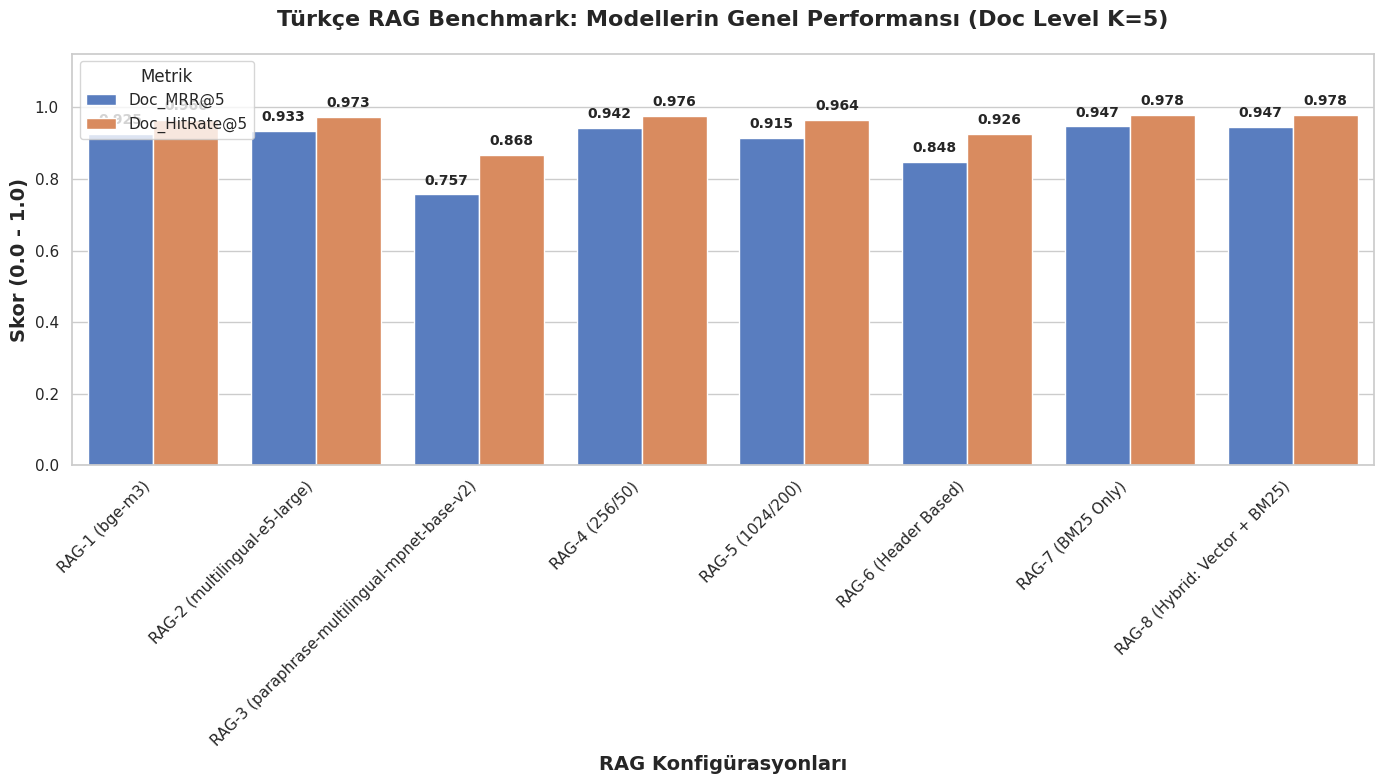

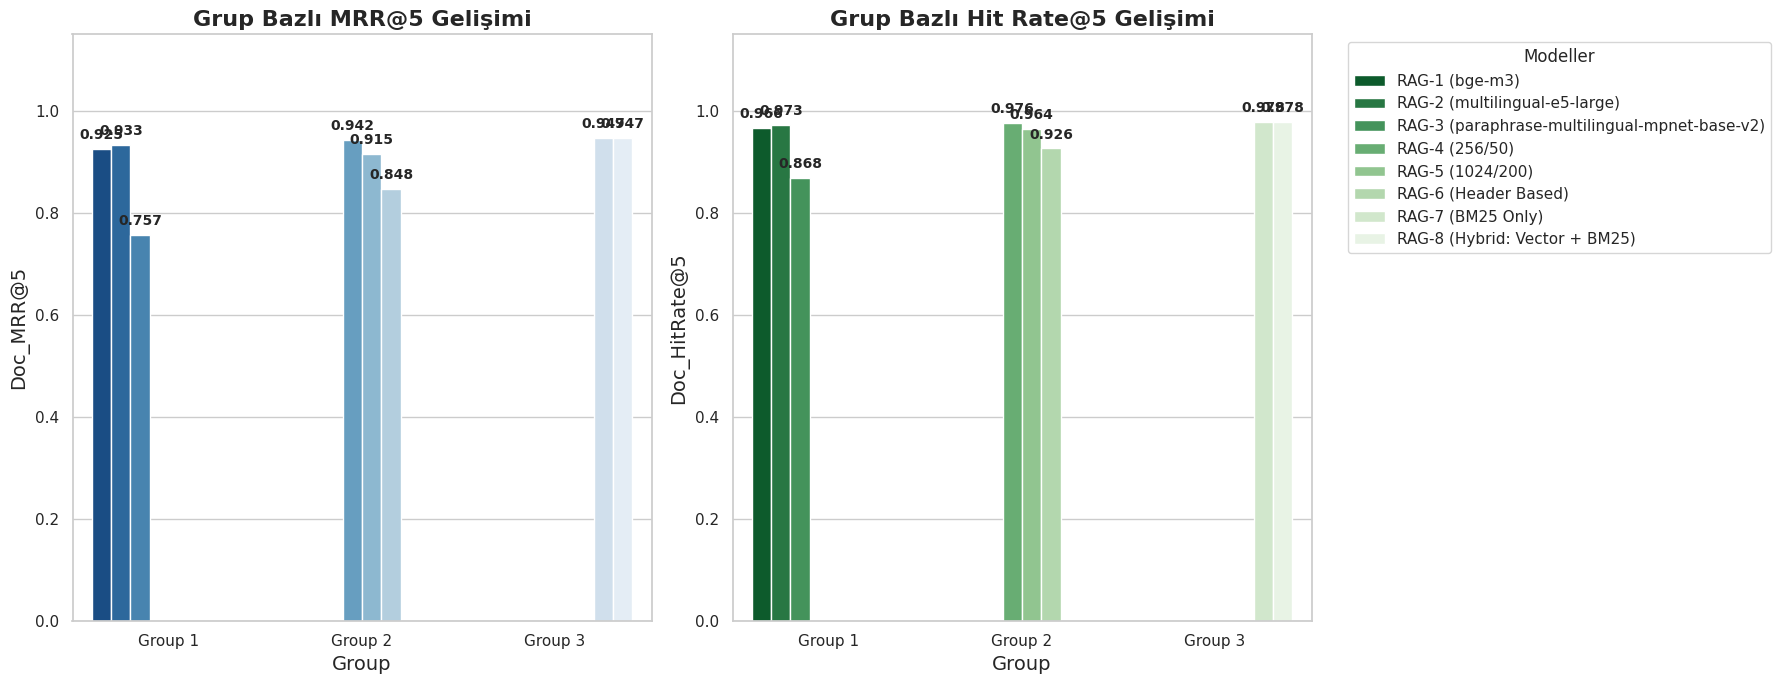

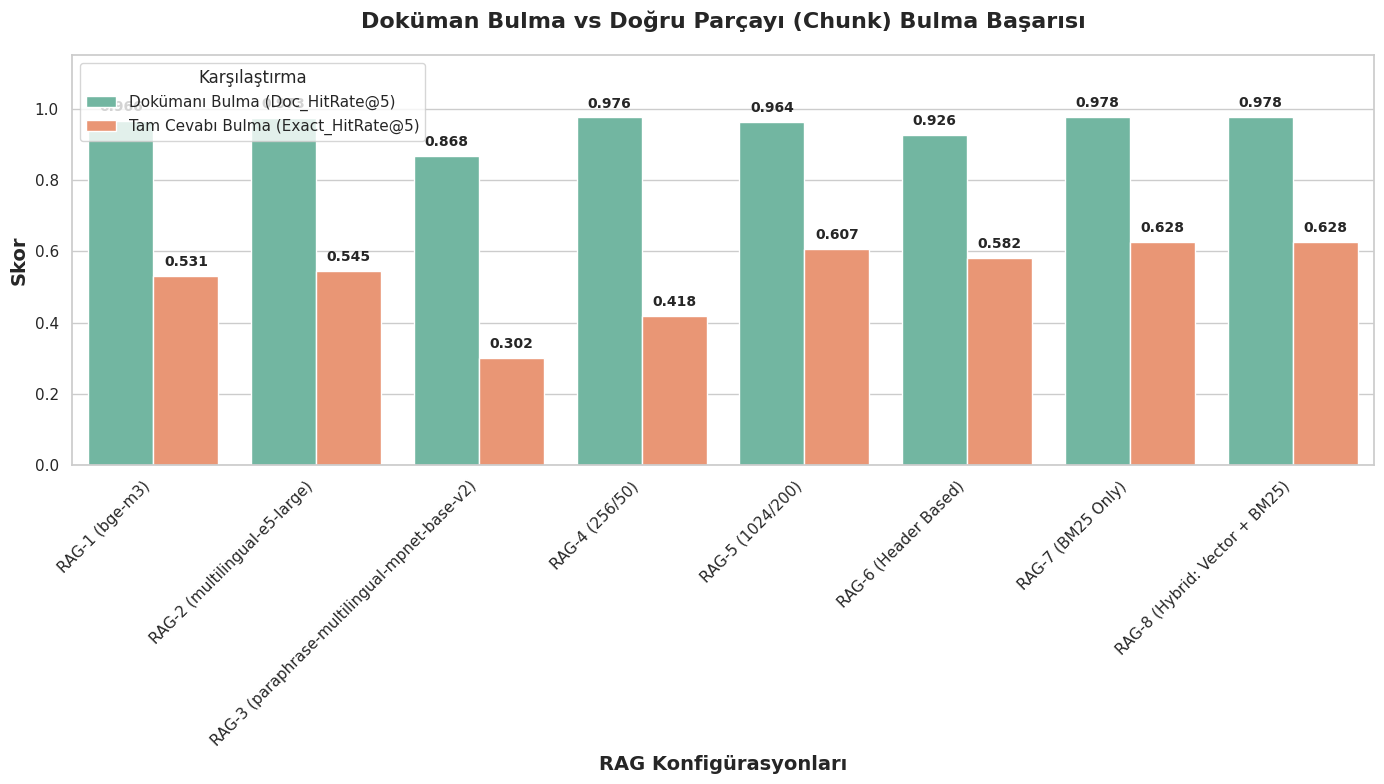

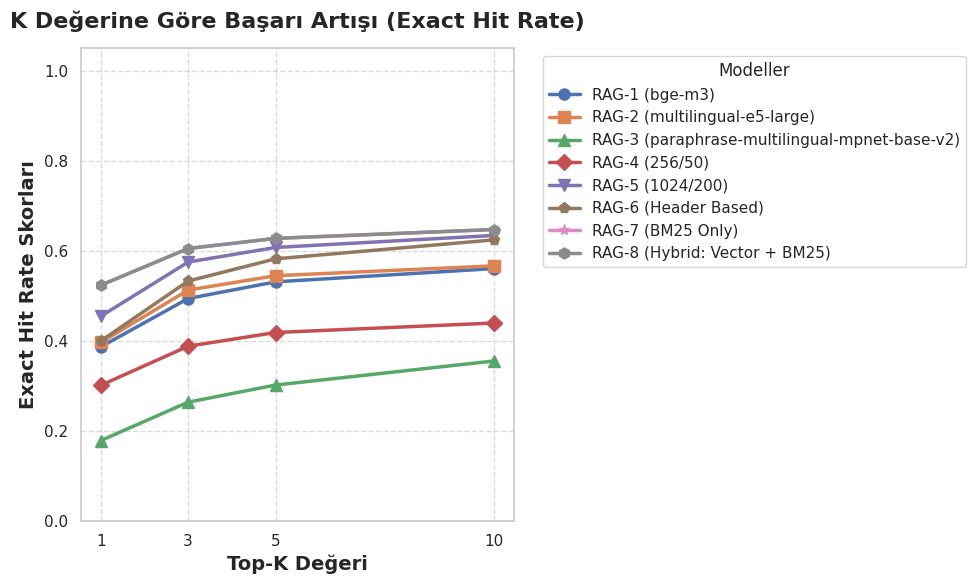

📊 Tüm (8 konfigürasyon) performans grafikleri './results/figures' dizinine kaydedildi!


In [8]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Klasör Oluşturma
output_dir = "./results/figures"
os.makedirs(output_dir, exist_ok=True)

# Grafik Stil Ayarları
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.titlesize": 18,
})

df_plot = pd.DataFrame(all_results)
df_plot = df_plot.rename(columns={"System": "Model"})

# 3 Basamaklı Annotation (Virgülden Sonra 3 Hane)
def add_annotations(ax, format_str="{:.3f}"):
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(format_str.format(height),
                        xy=(p.get_x() + p.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha="center", va="bottom", fontsize=10, fontweight="semibold", rotation=0)

# GRAFİK 1: TÜM MODELLERİN KARŞILAŞTIRILMASI (Doc_MRR@5 vs Doc_HitRate@5)
fig, ax = plt.subplots(figsize=(14, 8))
df_melted_1 = df_plot.melt(
    id_vars=["Model"],
    value_vars=["Doc_MRR@5", "Doc_HitRate@5"],
    var_name="Metrik",
    value_name="Skor",
)
sns.barplot(data=df_melted_1, x="Model", y="Skor", hue="Metrik", palette="muted", ax=ax)
ax.set_title("Türkçe RAG Benchmark: Modellerin Genel Performansı (Doc Level K=5)", pad=20, fontweight="bold")
ax.set_xlabel("RAG Konfigürasyonları", fontweight="bold")
ax.set_ylabel("Skor (0.0 - 1.0)", fontweight="bold")
ax.set_ylim(0, 1.15)
plt.xticks(rotation=45, ha="right")
add_annotations(ax)
plt.legend(title="Metrik", loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "overall_performance.png"), dpi=300)
plt.show()

# GRAFİK 2: GRUP BAZLI GELİŞİM (Grup 1 -> 2 -> 3)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(data=df_plot, x="Group", y="Doc_MRR@5", hue="Model", dodge=True, palette="Blues_r", ax=ax1)
ax1.set_title("Grup Bazlı MRR@5 Gelişimi", fontweight="bold")
ax1.set_ylim(0, 1.15)
ax1.get_legend().remove()
add_annotations(ax1)

sns.barplot(data=df_plot, x="Group", y="Doc_HitRate@5", hue="Model", dodge=True, palette="Greens_r", ax=ax2)
ax2.set_title("Grup Bazlı Hit Rate@5 Gelişimi", fontweight="bold")
ax2.set_ylim(0, 1.15)
ax2.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Modeller")
add_annotations(ax2)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "progression_by_groups.png"), dpi=300)
plt.show()

# GRAFİK 3: DOC LEVEL vs EXACT CHUNK LEVEL KARŞILAŞTIRMASI
fig, ax = plt.subplots(figsize=(14, 8))
df_melted_2 = df_plot.melt(
    id_vars=["Model"],
    value_vars=["Doc_HitRate@5", "Exact_HitRate@5"],
    var_name="Metrik Seviyesi",
    value_name="Skor",
)
df_melted_2["Metrik Seviyesi"] = df_melted_2["Metrik Seviyesi"].replace({
    "Doc_HitRate@5": "Dokümanı Bulma (Doc_HitRate@5)",
    "Exact_HitRate@5": "Tam Cevabı Bulma (Exact_HitRate@5)"
})
sns.barplot(data=df_melted_2, x="Model", y="Skor", hue="Metrik Seviyesi", palette="Set2", ax=ax)
ax.set_title("Doküman Bulma vs Doğru Parçayı (Chunk) Bulma Başarısı", pad=20, fontweight="bold")
ax.set_xlabel("RAG Konfigürasyonları", fontweight="bold")
ax.set_ylabel("Skor", fontweight="bold")
ax.set_ylim(0, 1.15)
plt.xticks(rotation=45, ha="right")
add_annotations(ax)
plt.legend(title="Karşılaştırma", loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "doc_vs_exact_hitrate.png"), dpi=300)
plt.show()

# GRAFİK 4: TOP-K BAŞARIM EĞRİSİ (HitRate @1, @3, @5, @10)
k_values = [1, 3, 5, 10]
hitrate_cols = [f"Exact_HitRate@{k}" for k in k_values]

fig, ax = plt.subplots(figsize=(10, 6))
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h']
for idx, row in df_plot.iterrows():
    # Güvenlik için eger metrik yoksa 0 al (farkli K degerleri tanimlanmadiysa diye)
    y_vals = [row.get(col, 0) for col in hitrate_cols]
    ax.plot(k_values, y_vals, marker=markers[idx % len(markers)], markersize=8, linewidth=2.5, label=row['Model'])

ax.set_title("K Değerine Göre Başarı Artışı (Exact Hit Rate)", pad=15, fontweight="bold")
ax.set_xlabel("Top-K Değeri", fontweight="bold")
ax.set_ylabel("Exact Hit Rate Skorları", fontweight="bold")
ax.set_xticks(k_values)
ax.set_ylim(0, 1.05)
ax.legend(title="Modeller", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "top_k_curve.png"), dpi=300)
plt.show()

print(f"📊 Tüm ({len(df_plot)} konfigürasyon) performans grafikleri '{output_dir}' dizinine kaydedildi!")

